/tmp/ipykernel_4067243/1613909176.py:230: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="Model", y="VG_Vp", order=order, palette=palette_F, errorbar="se", capsize=0.1, err_kws={'linewidth': 2.0}, edgecolor="black", linewidth=1.5, width=0.6, alpha=0.9, ax=ax, zorder=2)
/tmp/ipykernel_4067243/1613909176.py:247: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=TICK_FONT, fontweight='bold')
/tmp/ipykernel_4067243/1613909176.py:230: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="Model", y="VG_Vp", order=order, palette=palette_F, errorbar="se", capsize=0.1, err_kws={'l

📊 大图已保存 -> /home/s3020226030/1_rSV/01_human_chm13/20_plot/fig5_modified.pdf


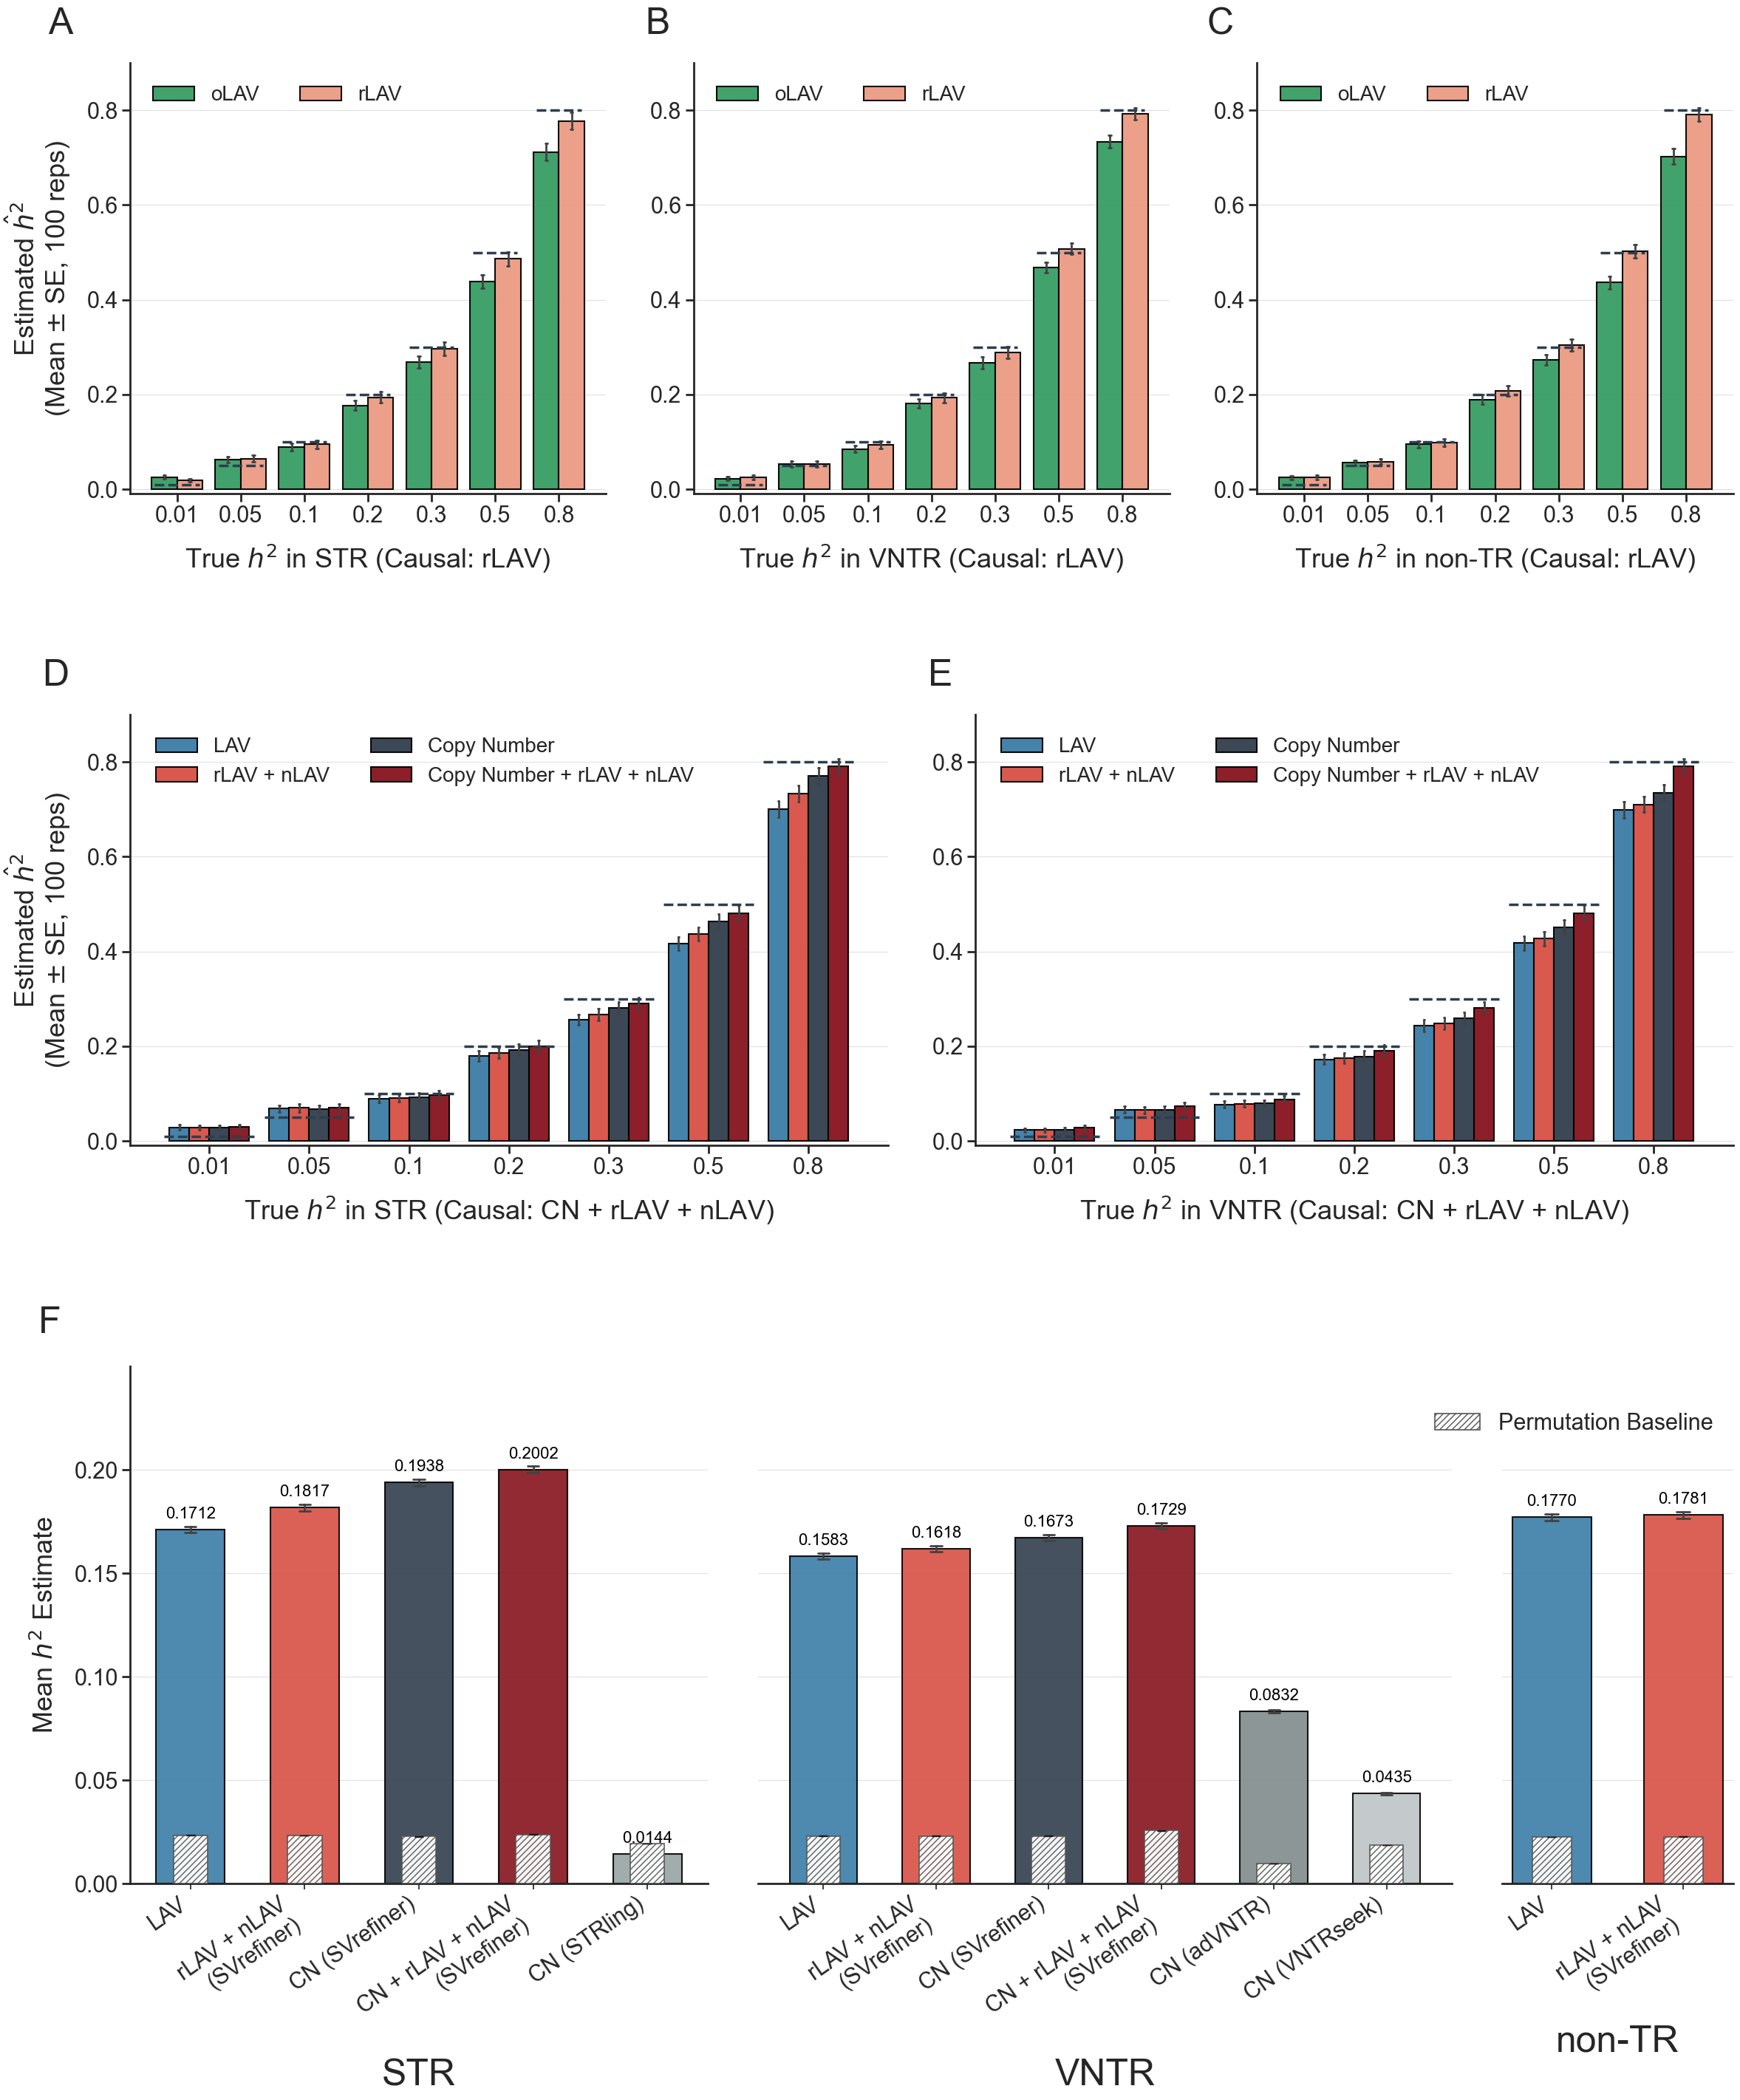

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# ==========================================
# 🎛️ Core Parameters & Global Settings
# ==========================================
MAX_HSQ = 0.8
Y_LIMIT_MAX = MAX_HSQ + 0.1
N_REPS = 100

# Global base paths
BASE_DIR_SIM = "/home/s3020226030/1_rSV/01_human_chm13"
BASE_DIR_REAL = "/home/s3020226030/1_rSV/01_human_chm13/25_hsq_real_data"

# Global font & style settings (SCI standard)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
sns.set_theme(style="ticks", rc={"axes.grid": True, "grid.color": "#e0e0e0", "axes.axisbelow": True})

# 📈 Enlarge fonts significantly
LABEL_FONT = 26       # X/Y axis large labels
TICK_FONT = 22        # Axis tick numeric labels
TITLE_FONT = 36       # 🚀 Layer 3 subplot titles (STR/VNTR/non-TR) 
LEGEND_FONT = 22      # Legend font
PANEL_LABEL_FONT = 36 # Panel labels A-F (enlarged and heavy)
ANNO_FONT = 16        # Annotation values on the 3rd layer bars

# ==========================================
# 🛠️ Helper function: Load & clean simulation data (Panels A-E)
# ==========================================
def load_sim_data(out_dir):
    final_tsv = f"{out_dir}/raw_simulation_results.tsv"
    if not os.path.exists(final_tsv):
        print(f"⚠️ Result file not found: {final_tsv}")
        return pd.DataFrame()
    df = pd.read_csv(final_tsv, sep='\t').dropna(subset=['est_hsq'])
    return df[df['true_hsq'] <= MAX_HSQ].copy()

# ==========================================
# 🛠️ Helper function: Plot simulation bar charts (Panels A-E)
# ==========================================
def plot_sim_barplot(ax, df, model_rename, order_list, palette, xlabel, hline_offset, capsize, ncol, show_ylabel=True):
    if df.empty:
        return
    
    # Filter and rename
    df = df[df['model'].isin(model_rename.keys())].copy()
    df['Model_Label'] = df['model'].map(model_rename)
    
    # Grid and spines
    ax.xaxis.grid(False)
    ax.yaxis.grid(True, linestyle='-', linewidth=0.8)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(2.0)
    sns.despine(ax=ax, top=True, right=True)

    # Draw plot
    sns.barplot(
        data=df, x='true_hsq', y='est_hsq', hue='Model_Label', hue_order=order_list,
        palette=palette, errorbar='se', capsize=capsize, err_kws={'linewidth': 2.0},
        linewidth=1.5, edgecolor="black", alpha=0.95, ax=ax
    )

    # Add Ground Truth reference lines
    hsq_levels = sorted(df['true_hsq'].unique())
    for i, hsq in enumerate(hsq_levels):
        ax.hlines(y=hsq, xmin=i-hline_offset, xmax=i+hline_offset, color='#2c3e50', linestyle='--', linewidth=2.5, zorder=10)

    # Ticks and labels
    ax.set_xlabel(xlabel, fontsize=LABEL_FONT, labelpad=15, fontweight='bold')
    
    # 🎯 Only show Y-axis label on the first column, integrating '100 reps'
    if show_ylabel:
        ax.set_ylabel(f'Estimated $\hat{{h}}^2$\n(Mean $\pm$ SE, {N_REPS} reps)', fontsize=LABEL_FONT, labelpad=15, fontweight='bold')
    else:
        ax.set_ylabel("")
        
    ax.tick_params(axis='both', which='major', labelsize=TICK_FONT, width=2.0, length=8)
    ax.set_ylim(-0.01, Y_LIMIT_MAX)

    # Legend
    ax.legend(title='', fontsize=LEGEND_FONT, loc='upper left', frameon=False, ncol=ncol,
              bbox_to_anchor=(0.01, 0.99), prop={'weight': 'bold', 'size': LEGEND_FONT-2})

# ==========================================
# 📦 Data Preparation: Panels A, B, C
# ==========================================
model_rename_ABC = {'0_Oracle_Causal': 'Causal', 'rLAV': 'rLAV', 'oLAV': 'oLAV'}
order_ABC = ['oLAV', 'rLAV']
palette_ABC = ['#27ae60', '#fc9272']

df_A = load_sim_data(f"{BASE_DIR_SIM}/24_hsq_simulation/real_data_simulation/results_rLAV_vs_oLAV_100reps_STR")
df_B = load_sim_data(f"{BASE_DIR_SIM}/24_hsq_simulation/real_data_simulation/results_rLAV_vs_oLAV_100reps_VNTR")
df_C = load_sim_data(f"{BASE_DIR_SIM}/24_hsq_simulation/real_data_simulation/results_rLAV_vs_oLAV_100reps_nonTR")

# ==========================================
# 📦 Data Preparation: Panels D, E
# ==========================================
model_rename_DE = {'CN': 'Copy Number', 'LAV': 'LAV', 'rLAV_nLAV': 'rLAV + nLAV', 'Joint_Pruned_05': 'Copy Number + rLAV + nLAV'}
order_DE = ['LAV', 'rLAV + nLAV', 'Copy Number', 'Copy Number + rLAV + nLAV']
palette_DE = ['#2980b9', '#ef3b2c', '#2c3e50', '#99000d']

df_D = load_sim_data(f"{BASE_DIR_SIM}/24_hsq_simulation/real_data_simulation/results_STR_prebuilt_GRMs_Mixed_causal_pruned_pool_100reps")
df_E = load_sim_data(f"{BASE_DIR_SIM}/24_hsq_simulation/real_data_simulation/results_VNTR_prebuilt_GRMs_Mixed_causal_pruned_pool_100reps")

# ==========================================
# 📦 Data Preparation: Panel F (Real Data)
# ==========================================
NAME_LAV = 'LAV'
NAME_RLAV = 'rLAV + nLAV\n(SVrefiner)'
NAME_CN = 'CN (SVrefiner)'
NAME_JOINT = 'CN + rLAV + nLAV\n(SVrefiner)'
NAME_STRLING = 'CN (STRling)'
NAME_ADVNTR = 'CN (adVNTR)'
NAME_VNTRSEEK = 'CN (VNTRseek)'

order_str = [NAME_LAV, NAME_RLAV, NAME_CN, NAME_JOINT, NAME_STRLING]
order_vntr = [NAME_LAV, NAME_RLAV, NAME_CN, NAME_JOINT, NAME_ADVNTR, NAME_VNTRSEEK]
order_nontr = [NAME_LAV, NAME_RLAV]

def load_real_data(file_path, models_to_keep=None, rename_dict=None, force_model_name=None):
    if not os.path.exists(file_path): return pd.DataFrame()
    df = pd.read_csv(file_path, sep='\t')
    df['VG_Vp'] = pd.to_numeric(df['VG_Vp'], errors='coerce')
    df = df.dropna(subset=['VG_Vp']).copy()
    if force_model_name: df['Model'] = force_model_name
    elif models_to_keep: df = df[df['Model'].isin(models_to_keep)].copy()
    if rename_dict: df['Model'] = df['Model'].map(rename_dict).fillna(df['Model'])
    return df

rename_main = {'LAV': NAME_LAV, 'rLAV_nLAV': NAME_RLAV}

# STR
df_str_main = load_real_data(f"{BASE_DIR_REAL}/01_WG_hsq_comparison_ManualGRM_raw_STR/summary_WG_ManualExactGRM.tsv", ['LAV', 'rLAV_nLAV'], rename_main)
df_str_cn = load_real_data(f"{BASE_DIR_REAL}/04_WG_hsq_comparison_ManualGRM_LAV_CN/summary_WG_ManualExactGRM_LAV_Final.tsv", ['LAV_STR'], {'LAV_STR': NAME_CN})
df_str_oth = load_real_data(f"{BASE_DIR_REAL}/03_WG_hsq_comparison_ManualGRM_TRs_raw/summary_WG_ManualExactGRM_TRs_Final.tsv", ['STR'], {'STR': NAME_STRLING})
df_str_joint = load_real_data(f"{BASE_DIR_REAL}/09_Test_Pruned_Joint_REML/summary_STR_r2_0.05.tsv", force_model_name=NAME_JOINT)
df_str_real = pd.concat([df_str_main, df_str_cn, df_str_oth, df_str_joint], ignore_index=True)

# VNTR
df_vntr_main = load_real_data(f"{BASE_DIR_REAL}/01_WG_hsq_comparison_ManualGRM_raw_VNTR/summary_WG_ManualExactGRM.tsv", ['LAV', 'rLAV_nLAV'], rename_main)
df_vntr_cn = load_real_data(f"{BASE_DIR_REAL}/04_WG_hsq_comparison_ManualGRM_LAV_CN/summary_WG_ManualExactGRM_LAV_Final.tsv", ['LAV_VNTR'], {'LAV_VNTR': NAME_CN})
df_vntr_oth = load_real_data(f"{BASE_DIR_REAL}/03_WG_hsq_comparison_ManualGRM_TRs_raw/summary_WG_ManualExactGRM_TRs_Final.tsv", ['adVNTR', 'VNTRseek'], {'adVNTR': NAME_ADVNTR, 'VNTRseek': NAME_VNTRSEEK}) 
df_vntr_joint = load_real_data(f"{BASE_DIR_REAL}/09_Test_Pruned_Joint_REML/summary_VNTR_r2_0.05.tsv", force_model_name=NAME_JOINT)
df_vntr_real = pd.concat([df_vntr_main, df_vntr_cn, df_vntr_oth, df_vntr_joint], ignore_index=True)

# non-TR
df_nontr_real = load_real_data(f"{BASE_DIR_REAL}/01_WG_hsq_comparison_ManualGRM_raw_nonTR/summary_WG_ManualExactGRM.tsv", ['LAV', 'rLAV_nLAV'], rename_main)


# ==========================================
# 🚧 Modified Section: Permutation baseline
# ==========================================
all_perm_dfs = []
models_to_replace = ['TRs_STR', 'TRs_adVNTR', 'TRs_VNTRseek']

# 1. Load old permutation data (filter out the three models to be replaced)
old_perm_files = glob.glob(f"{BASE_DIR_REAL}/05_WG_hsq_permutation/results/summary_Synced_Permutation_rep*.tsv") + \
                 glob.glob(f"{BASE_DIR_REAL}/05_WG_hsq_permutation/results_pruned_joint_test/summary_Missing_GRMs_rep*.tsv")

for f in old_perm_files:
    temp_df = pd.read_csv(f, sep='\t')
    temp_df['VG_Vp'] = pd.to_numeric(temp_df['VG_Vp'], errors='coerce')
    temp_df = temp_df.dropna(subset=['VG_Vp'])
    # Exclude the three models to be replaced
    temp_df = temp_df[~temp_df['Model'].isin(models_to_replace)]
    all_perm_dfs.append(temp_df)

# 2. Load newly run permutation data for STRling, adVNTR, VNTRseek
new_perm_files = glob.glob(f"{BASE_DIR_REAL}/05_WG_hsq_permutation/results/summary_Synced_Permutation_TRs_raw_rep*.tsv")

for f in new_perm_files:
    temp_df = pd.read_csv(f, sep='\t')
    temp_df['VG_Vp'] = pd.to_numeric(temp_df['VG_Vp'], errors='coerce')
    temp_df = temp_df.dropna(subset=['VG_Vp'])
    # Keep only these three models (failsafe)
    temp_df = temp_df[temp_df['Model'].isin(models_to_replace)]
    all_perm_dfs.append(temp_df)

# Merge and calculate mean and standard error (SEM)
if all_perm_dfs:
    perm_stats = pd.concat(all_perm_dfs, ignore_index=True).groupby('Model')['VG_Vp'].agg(['mean', 'sem']).reset_index()
else:
    perm_stats = pd.DataFrame(columns=['Model', 'mean', 'sem'])
# ==========================================

perm_mapping = {
    'STR_LAV': ('STR', NAME_LAV), 'STR_rLAV_nLAV': ('STR', NAME_RLAV), 'CN_LAV_STR': ('STR', NAME_CN), 'CN_rLAV_nLAV_STR': ('STR', NAME_JOINT), 'TRs_STR': ('STR', NAME_STRLING),
    'VNTR_LAV': ('VNTR', NAME_LAV), 'VNTR_rLAV_nLAV': ('VNTR', NAME_RLAV), 'CN_LAV_VNTR': ('VNTR', NAME_CN), 'CN_rLAV_nLAV_VNTR': ('VNTR', NAME_JOINT), 'TRs_adVNTR': ('VNTR', NAME_ADVNTR), 'TRs_VNTRseek': ('VNTR', NAME_VNTRSEEK),
    'nonTR_LAV': ('non-TR', NAME_LAV), 'nonTR_rLAV_nLAV': ('non-TR', NAME_RLAV)
}
perm_dict = {'STR': {}, 'VNTR': {}, 'non-TR': {}}
for _, row in perm_stats.iterrows():
    if row['Model'] in perm_mapping:
        region, display_model = perm_mapping[row['Model']]
        perm_dict[region][display_model] = (row['mean'], row['sem'])

palette_F = {NAME_LAV: '#2980b9', NAME_RLAV: '#ef3b2c', NAME_CN: '#2c3e50', NAME_JOINT: '#99000d', NAME_STRLING: '#95a5a6', NAME_ADVNTR: '#7f8c8d', NAME_VNTRSEEK: '#bdc3c7'}

# ==========================================
# 🎨 Construct the layout for the composite figure (SCI standard large format)
# ==========================================
fig = plt.figure(figsize=(28, 32))
gs = GridSpec(3, 6, figure=fig, height_ratios=[1, 1, 1.2], hspace=0.48, wspace=0.45)

# --- 🎯 Helper function for consistent panel labeling ---
def add_panel_label(ax, label, x_offset):
    ax.text(x_offset, 1.05, label, transform=ax.transAxes, 
            fontsize=PANEL_LABEL_FONT, fontweight='heavy', va='bottom', ha='right')

# ------------------------------------
# 📌 Layer 1: Panels A, B, C (3 plots)
# ------------------------------------
axA = fig.add_subplot(gs[0, 0:2])
axB = fig.add_subplot(gs[0, 2:4])
axC = fig.add_subplot(gs[0, 4:6])

plot_sim_barplot(axA, df_A, model_rename_ABC, order_ABC, palette_ABC, 'True $h^2$ in STR (Causal: rLAV)', 0.35, 0.08, 2, show_ylabel=True)
plot_sim_barplot(axB, df_B, model_rename_ABC, order_ABC, palette_ABC, 'True $h^2$ in VNTR (Causal: rLAV)', 0.35, 0.08, 2, show_ylabel=False)
plot_sim_barplot(axC, df_C, model_rename_ABC, order_ABC, palette_ABC, 'True $h^2$ in non-TR (Causal: rLAV)', 0.35, 0.08, 2, show_ylabel=False)

add_panel_label(axA, 'A', x_offset=-0.12)
add_panel_label(axB, 'B', x_offset=-0.05)
add_panel_label(axC, 'C', x_offset=-0.05)

# ------------------------------------
# 📌 Layer 2: Panels D, E (2 plots)
# ------------------------------------
axD = fig.add_subplot(gs[1, 0:3])
axE = fig.add_subplot(gs[1, 3:6])

plot_sim_barplot(axD, df_D, model_rename_DE, order_DE, palette_DE, 'True $h^2$ in STR (Causal: CN + rLAV + nLAV)', 0.45, 0.05, 2, show_ylabel=True)
plot_sim_barplot(axE, df_E, model_rename_DE, order_DE, palette_DE, 'True $h^2$ in VNTR (Causal: CN + rLAV + nLAV)', 0.45, 0.05, 2, show_ylabel=False)

add_panel_label(axD, 'D', x_offset=-0.08)
add_panel_label(axE, 'E', x_offset=-0.03)

# ------------------------------------
# 📌 Layer 3: Panel F (Nested 3 subplots with shared Y-axis)
# ------------------------------------
gsF = gs[2, :].subgridspec(1, 3, width_ratios=[len(order_str), len(order_vntr), len(order_nontr)], wspace=0.1)
axF1 = fig.add_subplot(gsF[0])
axF2 = fig.add_subplot(gsF[1], sharey=axF1)
axF3 = fig.add_subplot(gsF[2], sharey=axF1)

def plot_real_subplot(ax, data, order, region_title, is_first=False):
    if data.empty: return
    ax.xaxis.grid(False)
    ax.yaxis.grid(True, linestyle='-', linewidth=0.8)
    
    sns.barplot(data=data, x="Model", y="VG_Vp", order=order, palette=palette_F, errorbar="se", capsize=0.1, err_kws={'linewidth': 2.0}, edgecolor="black", linewidth=1.5, width=0.6, alpha=0.9, ax=ax, zorder=2)
    
    x_positions = np.arange(len(order))
    for i, model_name in enumerate(order):
        if model_name in perm_dict[region_title]:
            p_mean, p_se = perm_dict[region_title][model_name]
            ax.bar(x_positions[i], p_mean, yerr=p_se, width=0.3, facecolor='white', edgecolor='#555555', hatch='////', linewidth=1.2, capsize=4, zorder=3, alpha=0.95)

    for axis in ['bottom', 'left', 'top', 'right']: ax.spines[axis].set_linewidth(2.0)
    sns.despine(ax=ax, top=True, right=True, left=not is_first)
    
    # ==========================================
    # 🎯 Modification: Move TITLE to X-Axis Label
    # ==========================================
    ax.set_title("") # Remove top title
    ax.set_xlabel(region_title, fontsize=TITLE_FONT, fontweight='bold', labelpad=20) # Apply to X-axis
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=TICK_FONT, fontweight='bold')
    
    if is_first:
        ax.set_ylabel("Mean $h^2$ Estimate", fontsize=LABEL_FONT, labelpad=15, fontweight='bold')
        ax.tick_params(axis='y', labelsize=TICK_FONT, width=2.0, length=8)
    else:
        ax.set_ylabel("")
        ax.tick_params(axis='y', left=False, labelleft=False)

    for p in ax.patches:
        if p.get_width() > 0.5 and pd.notnull(p.get_height()) and p.get_height() > 0:
            ax.annotate(format(p.get_height(), '.4f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', xytext=(0, 8), textcoords='offset points', fontsize=ANNO_FONT, fontweight='bold', color='black')

plot_real_subplot(axF1, df_str_real, order_str, "STR", is_first=True)
plot_real_subplot(axF2, df_vntr_real, order_vntr, "VNTR", is_first=False)
plot_real_subplot(axF3, df_nontr_real, order_nontr, "non-TR", is_first=False)

axF1.set_ylim(0, 0.25)
axF1.set_yticks([0, 0.05, 0.10, 0.15, 0.20])

perm_patch = mpatches.Patch(facecolor='white', edgecolor='#555555', hatch='////', linewidth=1.2, label='Permutation Baseline')
axF3.legend(handles=[perm_patch], loc='upper right', fontsize=LEGEND_FONT, frameon=False, bbox_to_anchor=(1.0, 0.95))

add_panel_label(axF1, 'F', x_offset=-0.12)

# ==========================================
# 💾 Save and display the figure
# ==========================================
plt.tight_layout() 

save_path = f"{BASE_DIR_SIM}/20_plot/fig5_modified.pdf"
plt.savefig(save_path, format='pdf', dpi=600, bbox_inches='tight')
print(f"📊 Composite figure saved -> {save_path}")

plt.show()